In [1]:
from kedro.io import DataCatalog
import yaml
import os
import pandas as pd
pd.set_option('display.max_columns', None)
# move to the root directory
os.chdir(os.path.dirname(os.getcwd()))

In [2]:
# load the catalog
with open("conf/base/catalog.yml") as f:
    conf_catalog = yaml.safe_load(f)
catalog = DataCatalog.from_config(conf_catalog)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/__init__.py:90: KedroDeprecationWarning: `tracking.JSONDataset` and `tracking.MetricsDataset` are deprecated. These datasets will be removed in kedro-datasets 7.0.0
  return _bootstrap._gcd_import(name[level:], package, level)


In [3]:
with open("conf/base/parameters_feature_selection.yml") as f:
    tmp = yaml.safe_load(f)

In [4]:
tmp

{'fs_params': {'target': 'Mood_State',
  'n_vars': 'all',
  'method': 'backward',
  'kwarg': 'GBM'}}

In [50]:
train_data = catalog.load('final_train_data')
test_data = catalog.load('final_test_data')

In [51]:
len(train_data.columns)

28

**Statistical tests:**
*   ttest_ind
> This is a test for the null hypothesis that 2 independent samples have identical average (expected) values. This test assumes that the populations have identical variances by default.
*   f_oneway
> The one-way ANOVA tests the null hypothesis that two or more groups have the same population mean. The test is applied to samples from two or more groups, possibly with differing sizes.


We will be selecting variables with low p-values

In [11]:
import xgboost as xgb

In [12]:
xgb_model = xgb.XGBClassifier(objective='multi:softprob', num_class=4)
    # {'objective': 'multi:softprob',
    # 'num_class': 4})

In [12]:
xgb_model.fit(train_data.drop('Mood_State', axis=1), train_data['Mood_State'].cat.codes.astype(int))
y_pred = xgb_model.predict(test_data.drop('Mood_State', axis=1))

In [13]:
from sklearn.model_selection import cross_val_score

In [ ]:
cross_val_score(xgb_model,
                train_data.drop(columns=['Mood_State']),
                train_data['Mood_State'].cat.codes,
                scoring='roc_auc_ovr')

array([0.51490468, 0.50961149, 0.50115162, 0.51788892, 0.47604539])

In [103]:
y_pred

array([3, 2, 2, 1, 3, 0, 3, 1, 1, 1, 0, 3, 1, 1, 2, 3, 3, 2, 2, 0, 1, 2,
       1, 3, 3, 2, 2, 1, 2, 1, 2, 0, 2, 1, 1, 1, 3, 1, 3, 3, 3, 2, 2, 1,
       1, 3, 0, 2, 2, 0, 3, 3, 2, 2, 1, 2, 2, 0, 1, 0, 0, 2, 3, 0, 3, 0,
       3, 1, 0, 3, 1, 3, 1, 3, 2, 1, 2, 3, 1, 0, 1, 1, 3, 2, 2, 2, 3, 3,
       3, 1, 2, 2, 3, 1, 2, 3, 3, 2, 1, 1, 2, 1, 2, 3, 3, 2, 1, 3, 2, 0,
       2, 3, 2, 1, 1, 1, 3, 3, 1, 3, 1, 2, 2, 1, 2, 2, 1, 3, 0, 1, 0, 2,
       1, 2, 1, 3, 0, 1, 1, 1, 3, 1, 2, 0, 2, 2, 1, 3, 1, 2, 3, 3, 3, 3,
       2, 1, 2, 3, 1, 3, 1, 0, 3, 1, 2, 2, 2, 1, 3, 2, 3, 2, 3, 2, 1, 3,
       2, 3, 3, 1, 2, 2, 1, 3, 3, 2, 1, 1, 3, 1, 3, 3, 1, 1, 1, 1, 0, 1,
       3, 0])

In [109]:
from sklearn.linear_model import LogisticRegression

In [16]:
from lightgbm import LGBMClassifier

In [110]:
log_model = LogisticRegression()

ModuleNotFoundError: No module named 'lightgbm'

In [111]:
log_model

LogisticRegression()

In [17]:
lgbt_model = LGBMClassifier(objective='multiclass')

In [18]:
cross_val_score(lgbt_model,
                train_data.drop(columns=['Mood_State']),
                train_data['Mood_State'].cat.codes,
                scoring='roc_auc_ovr')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2623
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 22
[LightGBM] [Info] Start training from score -1.437588
[LightGBM] [Info] Start training from score -1.313974
[LightGBM] [Info] Start training from score -1.424516
[LightGBM] [Info] Start training from score -1.373872
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

array([0.50486166, 0.48502165, 0.49822569, 0.5058842 , 0.49133691])

In [19]:
import optuna

In [ ]:
def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "n_estimators": 1000,
        "verbosity": 0,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.05, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, verbose=False)
    predictions = model.predict(X_val)
    rmse = mean_squared_error(y_val, predictions, squared=False)
    return rmse

In [ ]:
def objective(trial):
    x = train_data.drop(columns=['Mood_State'])
    y = train_data['Mood_State'].cat.codes,

    classifier_name = trial.suggest_categorical("classifier", ["SVC", "RandomForest"])
    if classifier_name == "SVC":
        svc_c = trial.suggest_float("svc_c", 1e-10, 1e10, log=True)
        classifier_obj = sklearn.svm.SVC(C=svc_c, gamma="auto")
    else:
        rf_max_depth = trial.suggest_int("rf_max_depth", 2, 32, log=True)
        classifier_obj = sklearn.ensemble.RandomForestClassifier(
            max_depth=rf_max_depth, n_estimators=10
        )

    score = sklearn.model_selection.cross_val_score(classifier_obj, x, y, n_jobs=-1, cv=3)
    accuracy = score.mean()
    return accuracy

In [ ]:
if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=100)
    print(study.best_trial)

In [ ]:
cross_val_score(lgbt_model,
                train_data.drop(columns=['Mood_State']),
                train_data['Mood_State'].cat.codes,
                scoring='roc_auc_ovr')

In [26]:
from xgboost import XGBClassifier

In [27]:
train_data

,HRV,GSR,Oxygen_Saturation,Heart_Rate,Ambient_Noise,Cognitive_Load,Mood_State,Psychological_State,Respiration_Rate,Skin_Temp,Focus_Duration,Task_Type,Age,Educational_Level,Study_Major,EEG_Power_Bands_D,EEG_Power_Bands_A,EEG_Power_Bands_B,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Gender_Female,Gender_Male,Gender_Other
0,-0.505583,0.132734,0.145168,0.512821,0.037035,2,Anxious,1.510000,0.500000,0.098074,0.996540,1.510000,0.636364,0,1.510000,0.592309,0.964652,0.247035,0.105263,0.000000,1,0,0
1,1.149875,0.462176,0.654858,0.384615,0.382067,1,Anxious,1.510000,0.916667,0.279347,0.352941,1.510000,0.363636,2,0.755000,0.585304,0.207153,0.515795,1.000000,0.736842,1,0,0
2,-0.779770,0.011239,0.818028,0.897436,0.206290,0,Anxious,0.755000,0.083333,0.878474,0.996540,0.755000,0.090909,2,0.503333,0.477501,0.542763,0.996457,0.315789,1.000000,0,1,0
3,1.273297,0.222217,0.688676,0.743590,0.054021,2,Anxious,0.755000,0.833333,0.543705,0.584775,1.510000,0.454545,1,1.510000,0.930447,0.186580,0.074991,0.894737,0.789474,0,0,1
4,-0.319434,0.478226,0.377533,0.769231,0.325387,0,Happy,0.503333,0.166667,0.269471,0.048443,0.755000,0.454545,0,0.755000,0.332488,0.963899,0.044045,1.000000,0.894737,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.304292,0.119392,0.047765,0.282051,0.003581,1,Anxious,1.507626,0.333333,0.544985,0.826990,1.525431,0.545455,2,1.527815,0.985078,0.894713,0.736869,0.421053,0.368421,1,0,0
796,-0.790088,0.419194,0.827090,0.538462,0.771301,2,Anxious,1.497525,0.416667,0.629506,0.131488,1.519561,0.818182,2,1.464053,0.901602,0.272816,0.443676,0.842105,0.631579,1,0,0
797,0.189973,0.778229,0.353227,0.205128,0.623850,2,Happy,1.586495,0.166667,0.631177,0.128028,1.512184,0.818182,0,1.543598,0.862115,0.182033,0.743387,0.578947,0.894737,1,0,0
798,-0.879652,0.151739,0.000898,0.769231,0.027954,1,Sad,1.490000,0.333333,0.058941,0.550173,1.517727,0.090909,1,1.522177,0.379565,0.711090,0.681027,0.631579,0.894737,0,0,1


In [86]:
target = 'Mood_State'
score_type = 'roc_auc_ovr'
def objective(trial):
    trial.set_user_attr('objective', 'multi:softprob')
    trial.set_user_attr('num_class', 4)
    xgb_params = {
    'objective': trial.user_attrs['objective'],
    'num_class': trial.user_attrs['num_class'],
    'max_depth': trial.suggest_int("max_depth", 2, 10),
    'min_child_weight': trial.suggest_int("min_child_weight", 1, 10),
    'gamma': trial.suggest_int("gamma", 1, 10),
    'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.5)
    }

    score = cross_val_score(XGBClassifier(**xgb_params),
                    train_data.drop(columns=[target]),
                    train_data[target].cat.codes,
                    scoring=score_type).mean()
    return score
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)
study.best_params

[I 2025-01-11 14:19:34,868] A new study created in memory with name: no-name-5ad90591-fc93-43db-81e6-631644a66cfb
[I 2025-01-11 14:19:35,430] Trial 0 finished with value: 0.49627913455414197 and parameters: {'max_depth': 5, 'min_child_weight': 1, 'gamma': 5, 'learning_rate': 0.3180185358847749}. Best is trial 0 with value: 0.49627913455414197.
[I 2025-01-11 14:19:35,936] Trial 1 finished with value: 0.5011639523455511 and parameters: {'max_depth': 2, 'min_child_weight': 4, 'gamma': 4, 'learning_rate': 0.17750520773237097}. Best is trial 1 with value: 0.5011639523455511.
[I 2025-01-11 14:19:36,442] Trial 2 finished with value: 0.49773520273024763 and parameters: {'max_depth': 8, 'min_child_weight': 1, 'gamma': 7, 'learning_rate': 0.42523398910941074}. Best is trial 1 with value: 0.5011639523455511.
[I 2025-01-11 14:19:36,963] Trial 3 finished with value: 0.4977320837362333 and parameters: {'max_depth': 6, 'min_child_weight': 9, 'gamma': 3, 'learning_rate': 0.13374298542594795}. Best is 

{'max_depth': 5,
 'min_child_weight': 1,
 'gamma': 2,
 'learning_rate': 0.29112366744292284}

In [92]:
res = study.best_params

In [93]:
res.update(study.best_trial.user_attrs)

In [94]:
res

{'max_depth': 5,
 'min_child_weight': 1,
 'gamma': 2,
 'learning_rate': 0.29112366744292284,
 'objective': 'multi:softprob',
 'num_class': 4}

In [91]:
study.best_trial.user_attrs

{'objective': 'multi:softprob', 'num_class': 4}

In [81]:
study.best_params

{'max_depth': 2,
 'min_child_weight': 5,
 'gamma': 2,
 'learning_rate': 0.21885181172405266}

In [145]:
# load the catalog
with open("conf/base/catalog.yml") as f:
    conf_catalog = yaml.safe_load(f)
catalog = DataCatalog.from_config(conf_catalog)

In [60]:
xgb_model = XGBClassifier(**catalog.load('XGB_optuna_params@json'))

In [68]:
xgb_model.fit(train_data.drop('Mood_State', axis=1), train_data['Mood_State'].cat.codes)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4506253418177882,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=0, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [104]:
from sklearn.metrics import roc_auc_score, accuracy_score

In [105]:
pred = xgb_model.predict_proba(test_data.drop('Mood_State', axis=1))

In [141]:
cat_mapping = dict(enumerate(test_data['Mood_State'].cat.categories))

In [144]:
[y for x,y in cat_mapping.items()]

['Anxious', 'Happy', 'Neutral', 'Sad']

In [110]:
roc_auc_score(test_data['Mood_State'].cat.codes, pred_proba, multi_class='ovr')

np.float64(0.5066858624143858)

In [73]:
from sklearn.linear_model import LogisticRegression

In [111]:
a = {
        'train_roc_auc': 1,
        'train_accuracy': 2,
        'test_roc_auc': 3,
        'test_accuracy': 4,
    }

In [115]:
res_1={}

In [116]:
res_1.update(a)

In [146]:
catalog.list()

['raw_data',
 'preprocessed_data',
 'train_data',
 'test_data',
 'processed_cat_train',
 'processed_cat_test',
 'processed_num_train',
 'processed_num_test',
 'final_train_data',
 'final_test_data',
 'feat_rank_stat_results',
 'feat_rank_corr_results',
 'feat_backward_results',
 'feat_forward_results',
 'train_model',
 'test_model',
 'selected_features',
 'initial_cv_score',
 'LR_optuna_params',
 'LR_optuna_params_',
 'LGBM_optuna_params',
 'LGBM_optuna_params_',
 'XGB_optuna_params',
 'XGB_optuna_params_',
 'models_evaluation',
 'y_train_preds',
 'y_test_preds',
 'plot_mood_state_distribution_px',
 'plot_HRV_distribution_px',
 'plot_GSR_distribution_px',
 'plot_Age_distribution_px',
 'plot_Heart_Rate_distribution_px',
 'plot_Gender_distribution_px',
 'plot_Task_Type_distribution_px',
 'plot_Educational_Level_distribution_px',
 'plot_Mood_State_by_Gender_distribution_px',
 'plot_Age_vs_Mood_State_px',
 'plot_Task_Type_vs_Educational_Level_px',
 'plot_Skin_Temp_vs_Mood_State_px',
 'plot

In [149]:
catalog.load('y_test_preds')

,Anxious_proba,Happy_proba,Neutral_proba,Sad_proba,true_label,model
0,0.203799,0.263066,0.187266,0.345869,Anxious,xgb
1,0.253324,0.258319,0.283457,0.204900,Happy,xgb
2,0.298436,0.222195,0.258977,0.220392,Neutral,xgb
3,0.259492,0.291833,0.242042,0.206633,Sad,xgb
4,0.144581,0.268339,0.396868,0.190213,Happy,xgb
...,...,...,...,...,...,...
195,0.200181,0.325448,0.317871,0.156499,Neutral,lgbm
196,0.211630,0.178526,0.193773,0.416071,Sad,lgbm
197,0.105455,0.362670,0.281852,0.250023,Sad,lgbm
198,0.179461,0.171277,0.139626,0.509636,Sad,lgbm


In [152]:
catalog.load('y_test_preds').head()

,Anxious_proba,Happy_proba,Neutral_proba,Sad_proba,true_label,model
0,0.221409,0.203305,0.183940,0.391345,Anxious,xgb
1,0.195716,0.262393,0.332871,0.209019,Happy,xgb
2,0.237963,0.239484,0.326524,0.196028,Neutral,xgb
3,0.267145,0.286598,0.255720,0.190538,Sad,xgb
4,0.089603,0.262095,0.400807,0.247495,Happy,xgb


In [153]:
catalog.load('y_train_preds').head()

,Anxious_proba,Happy_proba,Neutral_proba,Sad_proba,true_label,model
0,0.324880,0.165298,0.183306,0.326515,Anxious,xgb
1,0.297028,0.275105,0.196800,0.231067,Anxious,xgb
2,0.448670,0.223150,0.133611,0.194569,Anxious,xgb
3,0.414268,0.175649,0.247581,0.162501,Anxious,xgb
4,0.165729,0.404560,0.106926,0.322785,Happy,xgb


In [108]:
models = {
    'xgb': XGBClassifier(**catalog.load('XGB_optuna_params@json')),
    'lr': LogisticRegression(**catalog.load('LR_optuna_params@json')),
    'lgbm': LGBMClassifier(**catalog.load('LGBM_optuna_params@json'))
}

results = {}
for name, model in models.items():
    trained_model = model.fit(train_data.drop(columns=['Mood_State']), train_data['Mood_State'].cat.codes)
    pred_proba = trained_model.predict_proba(test_data.drop(columns=['Mood_State']))
    pred = trained_model.predict(test_data.drop(columns=['Mood_State']))
    results[name+'_roc_auc'] = float(roc_auc_score(test_data['Mood_State'].cat.codes, pred_proba, multi_class='ovr'))
    results[name+'_accuracy'] = accuracy_score(test_data['Mood_State'].cat.codes, pred)

[LightGBM] [Warning] min_gain_to_split is set=0.10936141188798973, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.10936141188798973
[LightGBM] [Warning] min_gain_to_split is set=0.10936141188798973, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.10936141188798973
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3155
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 22
[LightGBM] [Info] Start training from score -1.437588
[LightGBM] [Info] Start training from score -1.313974
[LightGBM] [Info] Start training from score -1.427116
[LightGBM] [Info] Start training from score -1.371406
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [102]:
results

{'xgb_roc_auc': 0.5355843014782509,
 'xgb_accuracy': 0.32,
 'lr_roc_auc': 0.5376557328634153,
 'lr_accuracy': 0.27,
 'lgbm_roc_auc': 0.5066858624143858,
 'lgbm_accuracy': 0.28}

In [54]:
from sklearn.metrics import confusion_matrix
import plotly.express as px

In [55]:
catalog.list()

['raw_data',
 'preprocessed_data',
 'train_data',
 'test_data',
 'processed_cat_train',
 'processed_cat_test',
 'processed_num_train',
 'processed_num_test',
 'final_train_data',
 'final_test_data',
 'feat_rank_stat_results',
 'feat_rank_corr_results',
 'train_model',
 'test_model',
 'selected_features',
 'initial_cv_score',
 'LR_optuna_params',
 'LR_optuna_params_',
 'LGBM_optuna_params',
 'LGBM_optuna_params_',
 'XGB_optuna_params',
 'XGB_optuna_params_',
 'models_evaluation',
 'y_train_preds',
 'y_test_preds',
 'plot_mood_state_distribution_px',
 'plot_HRV_distribution_px',
 'plot_GSR_distribution_px',
 'plot_Age_distribution_px',
 'plot_Heart_Rate_distribution_px',
 'plot_Gender_distribution_px',
 'plot_Task_Type_distribution_px',
 'plot_Educational_Level_distribution_px',
 'plot_Mood_State_by_Gender_distribution_px',
 'plot_Age_vs_Mood_State_px',
 'plot_Task_Type_vs_Educational_Level_px',
 'plot_Skin_Temp_vs_Mood_State_px',
 'plot_Heart_Rate_vs_HRV_px',
 'plot_Time_px',
 'plot_con

In [1]:
y_train_preds=catalog.load('y_train_preds')

NameError: name 'catalog' is not defined

In [85]:
y_train_preds

,Anxious_proba,Happy_proba,Neutral_proba,Sad_proba,true_label,model
0,0.248904,0.259575,0.208197,0.283324,Anxious,xgb
1,0.236501,0.263113,0.260881,0.239506,Anxious,xgb
2,0.260145,0.235132,0.252027,0.252697,Anxious,xgb
3,0.270100,0.237449,0.271308,0.221143,Anxious,xgb
4,0.259376,0.255965,0.242647,0.242012,Happy,xgb
...,...,...,...,...,...,...
795,0.657312,0.144511,0.112457,0.085720,Anxious,lgbm
796,0.789078,0.125427,0.045421,0.040074,Anxious,lgbm
797,0.042428,0.491031,0.075741,0.390800,Happy,lgbm
798,0.009856,0.064075,0.018017,0.908053,Sad,lgbm


In [58]:
y_test_preds=catalog.load('y_test_preds')

In [92]:
from sklearn.metrics import roc_curve, auc
df = y_test_preds.query('model=="xgb"')
models = df["model"].unique()
classes = ["Anxious", "Happy", "Neutral", "Sad"]

# Prepare data for Plotly Express
roc_data = []

for model in models:
    model_data = df[df["model"] == model]

    for cls in classes:
        # Binarize true labels for the current class
        true_labels = (model_data["true_label"] == cls).astype(int)
        
        # Get probabilities for the current class
        proba = model_data[f"{cls}_proba"]

        # Compute ROC curve
        fpr, tpr, _ = roc_curve(true_labels, proba)
        roc_auc = auc(fpr, tpr)

        # Append data for plotting
        roc_data.extend([
            {"FPR": f, "TPR": t, "Model": model, "Class": cls, "AUC": roc_auc} for f, t in zip(fpr, tpr)
        ])

# Create a DataFrame for ROC data
roc_df = pd.DataFrame(roc_data)

# Plot using Plotly Express
fig = px.line(
    roc_df, 
    x="FPR", 
    y="TPR", 
    color="Class", 
    line_group="Model",
    hover_data={"AUC": True, "Model": True, "Class": True},
    title="ROC Curves for Multiple Models"
)

In [93]:
fig

In [3]:
import pandas as pd

In [20]:
results = {
  "xgb_train_roc_auc": 0.99,
  "xgb_train_accuracy": 0.91,
  "xgb_test_roc_auc": 0.52,
  "xgb_test_accuracy": 0.27,
  "xgb_train_f1": 0.91,
  "xgb_test_f1": 0.26,
  "lr_train_roc_auc": 0.59,
  "lr_train_accuracy": 0.34,
  "lr_test_roc_auc": 0.54,
  "lr_test_accuracy": 0.24,
  "lr_train_f1": 0.33,
  "lr_test_f1": 0.23,
  "lgbm_train_roc_auc": 1,
  "lgbm_train_accuracy": 0.98,
  "lgbm_test_roc_auc": 0.51,
  "lgbm_test_accuracy": 0.28,
  "lgbm_train_f1": 0.98,
  "lgbm_test_f1": 0.26,
  "ada_train_roc_auc": 0.8,
  "ada_train_accuracy": 0.52,
  "ada_test_roc_auc": 0.53,
  "ada_test_accuracy": 0.27,
  "ada_train_f1": 0.52,
  "ada_test_f1": 0.26
}

In [21]:
df = pd.DataFrame(results, index=[0]).T.reset_index()
df['index']=df['index'].str.replace('roc_auc', 'rocauc')
df[['Model', 'Set', 'Measure']] = df['index'].str.split('_', expand=True)
df = df.drop(columns=['index']).rename(columns={0: 'Value'})
df = df[['Model', 'Set', 'Measure', 'Value']]

In [22]:
df['Model']=df['Model'].str.upper()
df['Measure']=df['Measure'].str.upper()

In [23]:
df

,Model,Set,Measure,Value
0,XGB,train,ROCAUC,0.99
1,XGB,train,ACCURACY,0.91
2,XGB,test,ROCAUC,0.52
3,XGB,test,ACCURACY,0.27
4,XGB,train,F1,0.91
5,XGB,test,F1,0.26
6,LR,train,ROCAUC,0.59
7,LR,train,ACCURACY,0.34
8,LR,test,ROCAUC,0.54
9,LR,test,ACCURACY,0.24


/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = gro

<Figure size 1000x600 with 0 Axes>

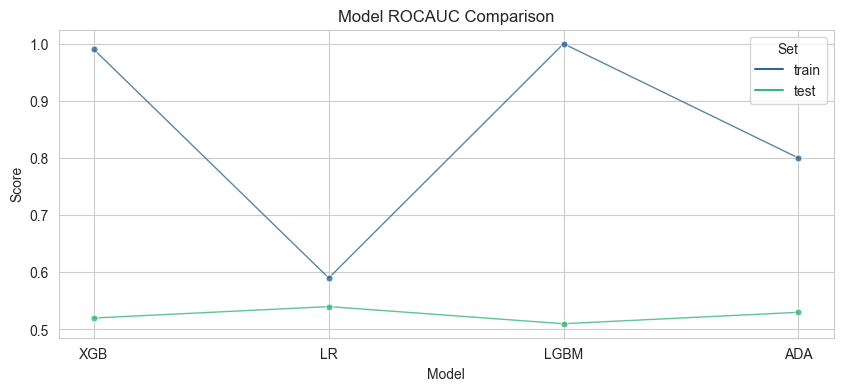

/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = gro

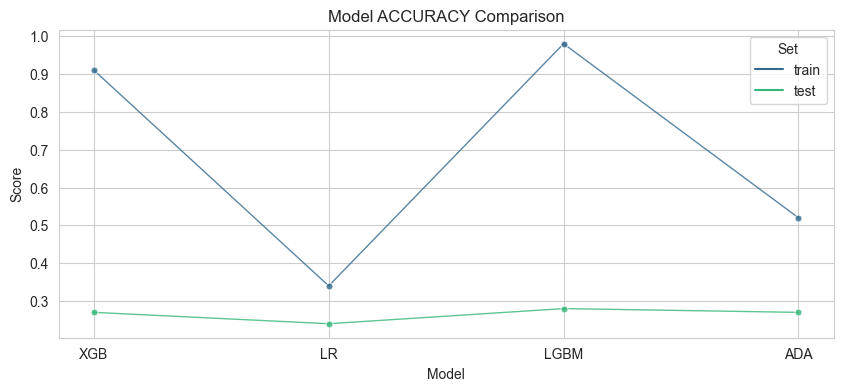

/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/anfrejter/Documents/GitHub/psychological-state-classification/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = gro

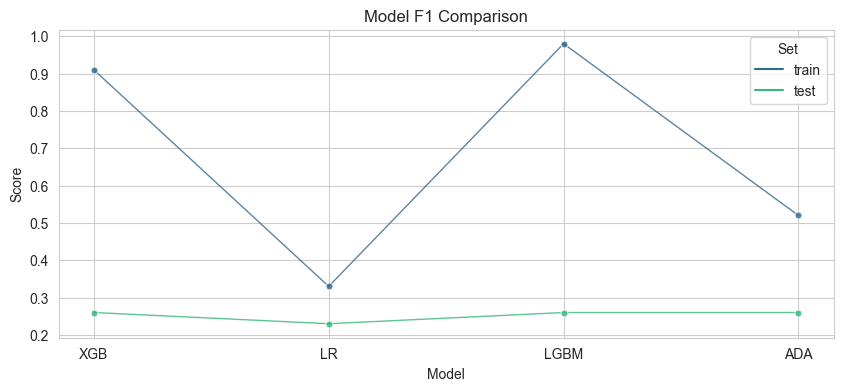

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create a grouped barplot
for measure in df.Measure.unique():
    sns.set_style("whitegrid")
    plt.figure(figsize=(10,4))
    sns.lineplot(data=df.query(f"Measure == '{measure}'"),
                x="Model", y="Value", hue="Set", palette="viridis", marker='o', markersize=5,alpha=0.8,linewidth=1)
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.title(f"Model {measure.upper()} Comparison")
    plt.legend(title="Set")
    plt.show()

In [25]:
pivot_df = df.pivot_table(index=['Model', 'Set'], columns='Measure', values='Value', aggfunc='first')
pivot_df = pivot_df.reset_index()

In [27]:
pivot_df

Measure,Model,Set,ACCURACY,F1,ROCAUC
0,ADA,test,0.27,0.26,0.53
1,ADA,train,0.52,0.52,0.80
2,LGBM,test,0.28,0.26,0.51
3,LGBM,train,0.98,0.98,1.00
4,LR,test,0.24,0.23,0.54
5,LR,train,0.34,0.33,0.59
6,XGB,test,0.27,0.26,0.52
7,XGB,train,0.91,0.91,0.99
